### Lifestyle of CF viruses

In [1]:
### Load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [2]:
### load UHGV integration data

# # Download genomad stats file
# !wget https://portal.nersc.gov/cfs/m342/UHGV/mysql/tsv/genomad_viral_stats.tsv

uhgv_proviruses = set(
    pl.read_csv('../figure_4/genomad_viral_stats.tsv', separator='\t', columns=['contig_id', 'provirus'])
    .filter(pl.col('provirus') == "Yes")
    ['contig_id']
)

In [3]:
### get OPD provirus info
# 1. download Excel sheet with metadata: https://static-content.springer.com/esm/art%3A10.1038%2Fs41522-025-00773-z/MediaObjects/41522_2025_773_MOESM2_ESM.xlsx
# 2. Filter Table3-OPD quality to identify 'replace_id' with 'checkv_provirus' == "Yes"
# 3. Save as TSV: opd_checkv_proviruses.tsv
opd_proviruses = set(
    pl.read_csv('../figure_4/opd_checkv_provirus.tsv', separator='\t', columns=['replace_id'])
    ['replace_id']
)

In [4]:
### Get CNGVC integration information
# CNGVC did not perform host trimming, so just used UHVDB provirus info

In [5]:
#### get CGVR provirus info
# 1. CGVR metadata downloaded from: https://static-content.springer.com/esm/art%3A10.1186%2Fs40168-025-02185-9/MediaObjects/40168_2025_2185_MOESM1_ESM.xlsx
# 2. Filter Table S1 to identify 'Viral_bin_id' with 'provirus' == "Yes"
# 3. Save as TSV: cgvr_checkv_proviruses.tsv
cgvr_proviruses = set(
    pl.read_csv('../figure_4/cgvr_checkv_proviruses.tsv', separator='\t', columns=['Viral_bin_id'])
    ['Viral_bin_id']
)

In [6]:
### get IMGVR integration info
# 1. Download IMGVR metadata from: https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR
imgvr_proviruses = set(
    pl.read_csv('../figure_1/IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology'])
        .filter(pl.col('Topology') == 'Provirus')
        ['UVIG']
)

In [7]:
### get mMGE provirus info
# 1. Download mMGE metadata from: https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
mmge_proviruses = set(
    pl.read_csv('../figure_1/all_mge_inf.csv')
        .filter(pl.col('prophage') == True)
        ['MGEs_id']
)

In [8]:
### load UHVDB r2025_09 info to identify Complete vs HQ viruses
uhvdb_info = (
    pl.read_csv(
        '../figure_2/vclust/uhvdb_vclust_cluster_info_final.tsv',
        separator='\t', columns=['contig_id', 'completeness_method', 'votu_rep']
    )
)

In [9]:
### load bacphlip results for UHVDB r2025_09
bacphlip_lst = []
for file in glob.glob('../figure_4/uhvdb_*/*.fna.bacphlip'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], new_columns=['contig_id', 'virulent', 'temperate'])
    )
    bacphlip_lst.append(df)

In [10]:
### Identify viruses detected in CF metagenomes
activity_data = (
    pl.read_csv('cf_metagenome_virus_activity_data.tsv', separator='\t')
        .filter(pl.col('breadth_ratio') >= 0.6)
)

In [11]:
### load UHVDB r2025_09 info to identify Complete vs HQ viruses
uhvdb_info = (
    pl.read_csv(
        '../uhvdb_cf_supplement/r2025_10_uhvdb_vclust_votu_cluster_info_final.tsv',
        separator='\t', columns=['contig_id', 'completeness_method', 'votu_rep']
    )
)

# identify complete genomes
complete_genomes = set(
    uhvdb_info
        .filter(pl.col('completeness_method').str.contains('TR'))
        ['contig_id']
)

In [12]:
### Extract CF viruses from host data
bacphlip_cf = (
    pl.concat(bacphlip_lst)
        .join(activity_data, on='contig_id', how='right')
)

bacphlip_df = (
    bacphlip_cf
        .with_columns([
            pl.when(pl.col('contig_id').str.contains('provirus'))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(uhgv_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(opd_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(cgvr_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(imgvr_proviruses))
                .then(pl.lit(1.0))
                .when(pl.col('contig_id').is_in(mmge_proviruses))
                .then(pl.lit(1.0))
                .otherwise(pl.col('temperate')).alias('temperate'),
            pl.when(pl.col('contig_id').is_in(complete_genomes))
                .then(pl.lit('Complete'))
                .otherwise(pl.lit('High-quality'))
                .alias('Completeness')
        ])
)

In [13]:
### Categorize CF viruses by their activity
cat_activity = (
    bacphlip_df
        .with_columns([
            pl.when(pl.col('activity_score') >= 3).then(pl.lit('High-confidence'))
            .when(pl.col('activity_score') >= 1).then(pl.lit('Low-confidence'))
            .otherwise(pl.lit('Unknown'))
            .alias('activity_category')
        ])
)

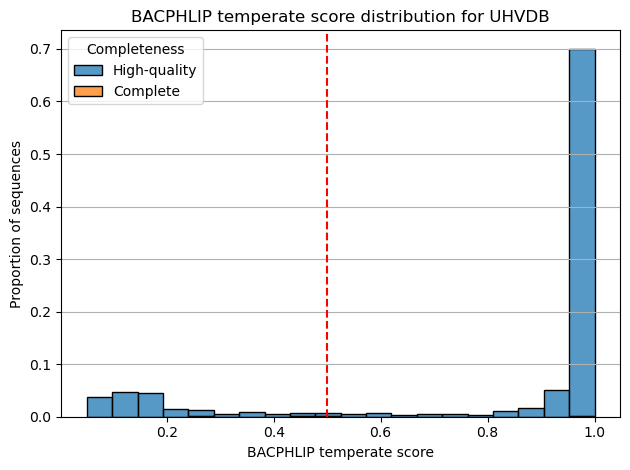

In [14]:
sns.histplot(data=cat_activity.filter(pl.col('activity_category') == 'Unknown'), x='temperate', stat='proportion', bins=20, hue='Completeness', multiple='stack', kde=False)
plt.xlabel('BACPHLIP temperate score')
plt.ylabel('Proportion of sequences')
plt.title('BACPHLIP temperate score distribution for UHVDB')
plt.grid(axis='y')
plt.tight_layout()
# add vertical line at 0.5
plt.axvline(x=0.5, color='red', linestyle='--')
plt.show()

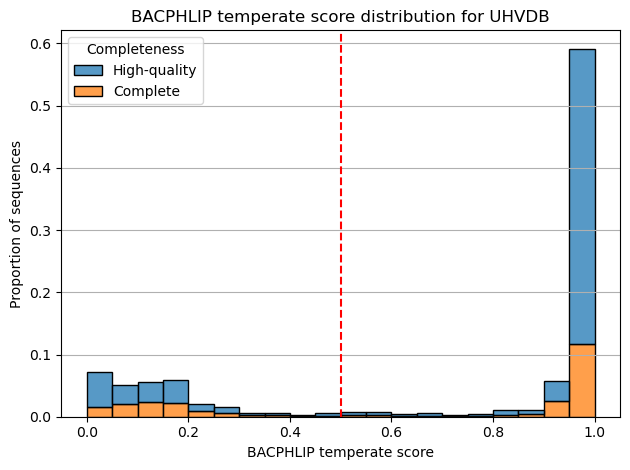

In [15]:
sns.histplot(data=cat_activity.filter(pl.col('activity_category') == 'Low-confidence'), x='temperate', stat='proportion', bins=20, hue='Completeness', multiple='stack', kde=False)
plt.xlabel('BACPHLIP temperate score')
plt.ylabel('Proportion of sequences')
plt.title('BACPHLIP temperate score distribution for UHVDB')
plt.grid(axis='y')
plt.tight_layout()
# add vertical line at 0.5
plt.axvline(x=0.5, color='red', linestyle='--')
plt.show()

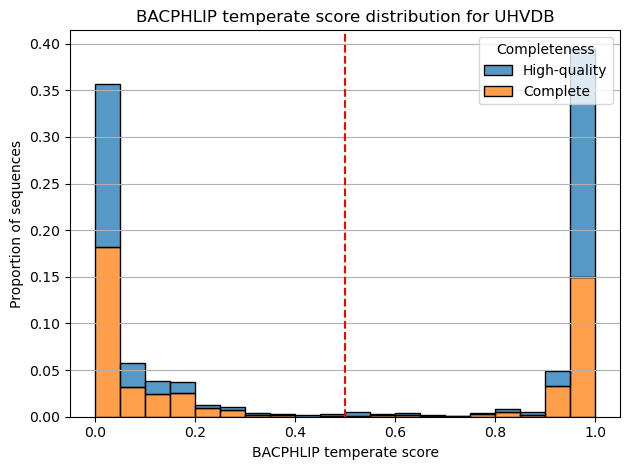

In [16]:
sns.histplot(data=cat_activity.filter(pl.col('activity_category') == 'High-confidence'), x='temperate', stat='proportion', bins=20, hue='Completeness', multiple='stack', kde=False)
plt.xlabel('BACPHLIP temperate score')
plt.ylabel('Proportion of sequences')
plt.title('BACPHLIP temperate score distribution for UHVDB')
plt.grid(axis='y')
plt.tight_layout()
# add vertical line at 0.5
plt.axvline(x=0.5, color='red', linestyle='--')
plt.show()

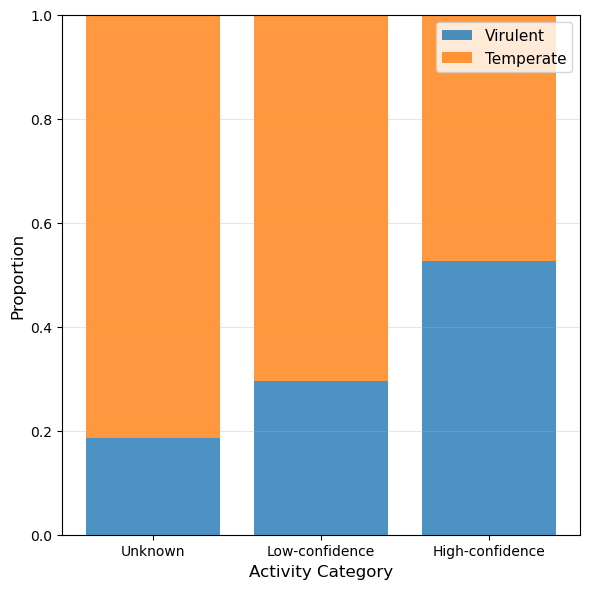

shape: (6, 5)
┌───────────────────┬───────────┬───────┬───────┬────────────┐
│ activity_category ┆ Lifestyle ┆ count ┆ total ┆ proportion │
│ ---               ┆ ---       ┆ ---   ┆ ---   ┆ ---        │
│ str               ┆ str       ┆ u32   ┆ u32   ┆ f64        │
╞═══════════════════╪═══════════╪═══════╪═══════╪════════════╡
│ High-confidence   ┆ Temperate ┆ 1627  ┆ 3427  ┆ 0.474759   │
│ High-confidence   ┆ Virulent  ┆ 1800  ┆ 3427  ┆ 0.525241   │
│ Low-confidence    ┆ Virulent  ┆ 7185  ┆ 24244 ┆ 0.296362   │
│ Low-confidence    ┆ Temperate ┆ 17059 ┆ 24244 ┆ 0.703638   │
│ Unknown           ┆ Temperate ┆ 18565 ┆ 22811 ┆ 0.813862   │
│ Unknown           ┆ Virulent  ┆ 4246  ┆ 22811 ┆ 0.186138   │
└───────────────────┴───────────┴───────┴───────┴────────────┘


In [17]:
### Create a stacked bar chart of the proportion classified as virulent and temperate by activity category

# Classify viruses as temperate (>= 0.5) or virulent (< 0.5)
plot_data = (
    cat_activity
        .with_columns([
            pl.when(pl.col('temperate') > 0.5)
                .then(pl.lit('Temperate'))
                .otherwise(pl.lit('Virulent'))
                .alias('Lifestyle')
        ])
        .group_by('activity_category', 'Lifestyle')
        .len('count')
        .with_columns(
            pl.col('count').sum().over('activity_category').alias('total')
        )
        .with_columns(
            (pl.col('count') / pl.col('total')).alias('proportion')
        )
)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(6, 6))

# Pivot data for plotting
pivot_data = plot_data.pivot(on='Lifestyle', index='activity_category', values='proportion', aggregate_function='first')

# Define activity category order
activity_order = ['Unknown', 'Low-confidence', 'High-confidence']
pivot_data = pivot_data.filter(pl.col('activity_category').is_in(activity_order))
pivot_data = pivot_data.sort(
    pl.col('activity_category').map_elements(lambda x: activity_order.index(x) if x in activity_order else -1, return_dtype=pl.Int32)
)

# Create the stacked bar chart
x_pos = range(len(pivot_data))
temperate_prop = pivot_data['Temperate'].to_list() if 'Temperate' in pivot_data.columns else [0] * len(pivot_data)
virulent_prop = pivot_data['Virulent'].to_list() if 'Virulent' in pivot_data.columns else [0] * len(pivot_data)

colors = sns.color_palette()[:2]
ax.bar(x_pos, virulent_prop, label='Virulent', color=colors[0], alpha=0.8)
ax.bar(x_pos, temperate_prop, bottom=virulent_prop, label='Temperate', color=colors[1], alpha=0.8)

# Customize the plot
ax.set_ylabel('Proportion', fontsize=12)
ax.set_xlabel('Activity Category', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(pivot_data['activity_category'].to_list())
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print proportions table
print(plot_data.sort('activity_category'))

In [18]:
bacphlip_df.write_csv('uhvdb_cf_virus_bacplhip.tsv', separator='\t')

In [19]:
cat_activity.with_columns([pl.when(pl.col('temperate') > 0.5).then(pl.lit('Temperate')).otherwise(pl.lit('Virulent')).alias('lifestyle')])

virulent,temperate,contig_id,sample_id,bioproject,num_bp,breadth_score,ref_dtr_score,ref_virulent_score,trimmed_mean,mean,breadth,breadth_ratio,True_cov_virus,completeness_method,virulent_right,dtr_score,num_oprs,num_clipped,CohenD,prophage-host_ratio,mvirs_score,propagate_score,activity_score,reference_activity_score,Completeness,activity_category,lifestyle
f64,f64,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str
0.0,1.0,"""ERZ1745176.30|provirus_2_12837""","""SAMN33100507_SRR23346275_cf""","""prjna931830""",5281372738,0.0,0.0,0.0,22.369505,38.17121,0.741586,0.741586,5.591,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,0.0,0.0,"""High-quality""","""Unknown""","""Temperate"""
0.0375,1.0,"""SAMEA10740079_k141_267543|prov…","""SAMN33100449_SRR23346039_cf""","""prjna931830""",376112381,1.0,0.0,0.0,21.561628,21.529776,0.840709,0.840709,20.069,"""AAI-based (high-confidence)""",0.0,3.0,12,1,null,null,3.0,0.0,7.0,1.0,"""High-quality""","""High-confidence""","""Temperate"""
0.811878,0.188122,"""ERR9968832_6045""","""SAMN33100461_SRR23346098_cf""","""prjna931830""",2301833552,1.0,0.0,0.0,6.4680104,6.6342363,0.931924,0.935648,5.498,"""AAI-based (medium-confidence)""",0.811878,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""High-quality""","""Low-confidence""","""Virulent"""
0.0,1.0,"""ERZ21616052.531""","""SAMN33100656_SRR23346206_cf""","""prjna931830""",6441599120,1.0,0.0,0.0,54.258415,58.23292,1.0,1.0,7.111,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""High-quality""","""Low-confidence""","""Temperate"""
0.0,1.0,"""SAMEA10740757_k141_310627|prov…","""SAMN33100554_SRR23346134_cf""","""prjna931830""",4436904814,0.0,0.0,0.0,7.0775237,11.562478,0.759584,0.759634,6.696,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,0.0,0.0,"""High-quality""","""Unknown""","""Temperate"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.920044,0.079956,"""opdg_17501""","""SAMEA14381369_ERR10814787_cf""","""prjeb52317""",38104488,0.0,0.0,0.0,1.2576104,1.3868122,0.612437,0.894055,0.667,"""AAI-based (high-confidence)""",0.920044,0.0,null,null,null,null,0.0,0.0,0.0,0.0,"""High-quality""","""Unknown""","""Virulent"""
0.980604,1.0,"""SAMEA10740915_k141_119376|prov…","""SAMN11135484_SRR8731634_cf""","""prjna516442""",1206253215,1.0,0.0,0.0,0.8982091,1.0227693,0.568475,0.991368,0.971,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""High-quality""","""Low-confidence""","""Temperate"""
0.05,1.0,"""SAMEA10741324_k141_203510|prov…","""SAMN40993700_SRR28721315_cf""","""prjna1101448""",429156884,1.0,0.0,0.0,0.485763,0.6016489,0.384176,0.97462,1.417,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""High-quality""","""Low-confidence""","""Temperate"""


In [20]:
high_prev = set(pl.read_csv('high_prev_cf_viruses.tsv', separator='\t')['contig_id'])

(
    cat_activity
        .with_columns([
            pl.when(pl.col('temperate') > 0.5).then(pl.lit('Temperate')).otherwise(pl.lit('Virulent')).alias('lifestyle')
        ])
        .filter(pl.col('contig_id').is_in(high_prev))
        [['lifestyle', 'contig_id']]
        .unique(subset=['contig_id'])
        .write_csv('high_prev_cf_virus_lifestyle.tsv', separator='\t')
        
)

In [22]:
high_cov = set(pl.read_csv('cf_pathogen_cov_active.tsv', separator='\t')['contig_id'])

(
    cat_activity
        .with_columns([
            pl.when(pl.col('temperate') > 0.5).then(pl.lit('Temperate')).otherwise(pl.lit('Virulent')).alias('lifestyle')
        ])
        .filter(pl.col('contig_id').is_in(high_cov))
        [['lifestyle', 'contig_id']]
        .unique(subset=['contig_id'])
        .write_csv('high_cov_cf_virus_lifestyle.tsv', separator='\t')
        
)